In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

vocab_size = len(itos)

In [ ]:
block_size = 8

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size

    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [ ]:
Xtr[11], Ytr[11]

(tensor([ 0,  0, 15, 12,  9, 22,  9,  1]), tensor(0))

In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn(fan_in, fan_out)
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.dim = dim
    self.training = True
    self.momentum = momentum

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var

    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    with torch.no_grad():
      self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
      self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weights = torch.randn(num_embeddings, embedding_dim)

  def __call__(self, IX):
    self.out = self.weights[IX]
    return self.out

  def parameters(self):
    return [self.weights]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if T//self.n == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
n_emb = 30
batch_size = 32
n_hidden = 100

model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
  for layer in model.layers:
    if isinstance(layer, Linear):
      layer.weights *= 5/3

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

50137


In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb

tensor([[ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0, 11,  1],
        [ 0,  0,  0, 11, 14, 15, 24, 24],
        [ 0,  0,  0,  0,  0, 18,  9,  4]])

In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', layer.out.shape)

Embedding : torch.Size([4, 8, 30])
FlattenConsecutive : torch.Size([4, 4, 60])
Linear : torch.Size([4, 4, 100])
BatchNorm1d : torch.Size([4, 4, 100])
Tanh : torch.Size([4, 4, 100])
FlattenConsecutive : torch.Size([4, 2, 200])
Linear : torch.Size([4, 2, 100])
BatchNorm1d : torch.Size([4, 2, 100])
Tanh : torch.Size([4, 2, 100])
FlattenConsecutive : torch.Size([4, 200])
Linear : torch.Size([4, 100])
BatchNorm1d : torch.Size([4, 100])
Tanh : torch.Size([4, 100])
Linear : torch.Size([4, 27])


In [ ]:
max_steps = 100000
lossi = []
g = torch.Generator().manual_seed(2147483647)

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()


  lr = 0.1 if i < 25000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  lossi.append(loss.log10().item())
  if (i+1) % 10000 == 0:
    print(f'{i+1}/{max_steps}| {loss.item():.4f}')



10000/100000| 2.3871
20000/100000| 2.7156
30000/100000| 2.2391
40000/100000| 2.2302
50000/100000| 2.1680
60000/100000| 2.4747
70000/100000| 2.2792
80000/100000| 2.2589
90000/100000| 1.9565
100000/100000| 1.7084


([<matplotlib.lines.Line2D at 0x78e09fc39af0>], torch.Size([200, 500]))

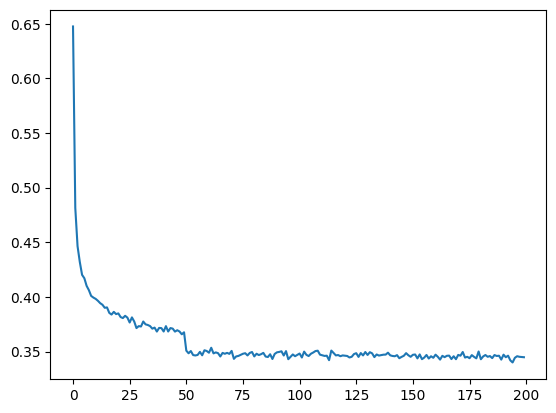

In [13]:
plt.plot(torch.tensor(lossi).view(-1, 500).mean(1)), torch.tensor(lossi).view(-1, 500).shape

In [19]:
# Needed for sampling(e.i. False when sampling and True when training)
for layer in model.layers:
  layer.training = False

In [21]:
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'test': (Xtest, Ytest),
      'val': (Xval, Yval)
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1920337677001953
val 2.425431251525879


In [22]:
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

maqwiyc.
abarlia.
sehla.
kaya.
yana.
heylee.
neleer.
dezep.
kwes.
siai.
ku.
emasshanlee.
kalres.
xrigir.
tayley.
angian.
mahteel.
litascn.
mavtligo.
shaidy.
